This notebook contains the generation of synthetic data based on the real Beijing dataset. Created utilizing the SDV library! https://datacebo.com/sdv-dev/

In [ ]:
# load the real data as a base + imports

import pandas as pd
from pathlib import Path
from sdv.single_table import GaussianCopulaSynthesizer
from sdv.metadata import Metadata

df = pd.read_csv(
    "data/real_pruned/clip_alpha_0.000.csv",
    parse_dates=["timestamp"]
)

df = df.sort_values("timestamp").reset_index(drop=True)

In [3]:
rows_in_dataset = 41757 # number of rows in the real dataset, used for sampling synthetic data
data = df
metadata = Metadata.detect_from_dataframe(data)
synthesizer = GaussianCopulaSynthesizer(metadata)
synthesizer.fit(data)
synthetic_data = synthesizer.sample(num_rows=rows_in_dataset)

c:\Users\lenni\Documents\Thesis\.venv\Lib\site-packages\sdv\single_table\base.py:134: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(


In [4]:
from sdv.evaluation.single_table import run_diagnostic
# evaluate the synthetic data against the real data using the diagnostic function from SDV
diagnostic = run_diagnostic(
    real_data=data,
    synthetic_data=synthetic_data,
    metadata=metadata
)

Generating report ...

(1/2) Evaluating Data Validity: |██████████| 9/9 [00:00<00:00, 491.32it/s]|
Data Validity Score: 100.0%

(2/2) Evaluating Data Structure: |██████████| 1/1 [00:00<00:00, 596.54it/s]|
Data Structure Score: 100.0%

Overall Score (Average): 100.0%



In [5]:
from sdv.evaluation.single_table import evaluate_quality
# evaluate the synthetic data against the real data using the evaluate_quality function from SDV
quality_report = evaluate_quality(
    real_data=data,
    synthetic_data=synthetic_data,
    metadata=metadata
)

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 9/9 [00:00<00:00, 60.59it/s]|
Column Shapes Score: 75.63%

(2/2) Evaluating Column Pair Trends: |██████████| 36/36 [00:00<00:00, 158.86it/s]|
Column Pair Trends Score: 98.92%

Overall Score (Average): 87.28%



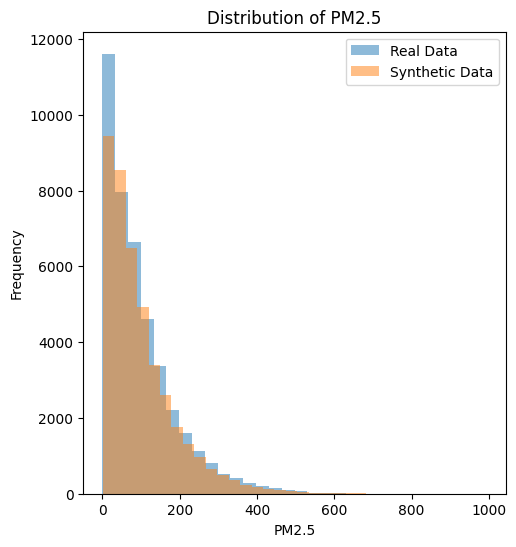

In [8]:
# sample plot to compare the distributions of a column in the real and synthetic data
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.hist(data["pm2.5"], bins=30, alpha=0.5, label="Real Data")
plt.hist(synthetic_data["pm2.5"], bins=30, alpha=0.5, label="Synthetic Data")
plt.title("Distribution of PM2.5")
plt.xlabel("PM2.5")
plt.ylabel("Frequency")
plt.legend()

In [9]:
# save synthetic dataset
alpha = 0.000
out_dir = Path("data/synthetic_pruned")
fname = out_dir / f"clip_alpha_{alpha:.3f}.csv"
out_dir.mkdir(exist_ok=True)
synthetic_data.to_csv(fname, index=False)